In [ ]:
import numpy as np 
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn import tree

In [ ]:
phis_df = pd.read_csv('D:\Google_Colab\Phishing Detection with decision tress\phishing_training.csv')

<>:1: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:1: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_11400\377386618.py:1: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  phis_df = pd.read_csv('D:\Google_Colab\Phishing Detection with decision tress\phishing_training.csv')


In [ ]:
phis_df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [ ]:
phis_df.shape

(11055, 31)

In [ ]:
phis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  int64
 14  L

In [ ]:
phis_df.isnull().sum()

having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistical_report             0
Result    

In [ ]:
phis_df['Result'].value_counts()

Result
 1    6157
-1    4898
Name: count, dtype: int64

In [ ]:
x = phis_df.drop(columns = 'Result')
y = phis_df['Result']

In [ ]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test  = train_test_split( x , y , test_size=0.2 , random_state=1 ,stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
x_train

array([[-1.37141597, -0.47702567,  0.39104165, ...,  0.39945551,
        -0.61343003,  0.40268481],
       [ 0.72917337, -0.47702567,  0.39104165, ..., -2.5034077 ,
        -0.61343003,  0.40268481],
       [-1.37141597,  2.13848271,  0.39104165, ...,  0.39945551,
         1.14399633,  0.40268481],
       ...,
       [ 0.72917337, -0.47702567,  0.39104165, ...,  0.39945551,
        -0.61343003,  0.40268481],
       [ 0.72917337, -0.47702567,  0.39104165, ..., -2.5034077 ,
         1.14399633,  0.40268481],
       [ 0.72917337, -0.47702567,  0.39104165, ...,  0.39945551,
        -0.61343003,  0.40268481]], shape=(8844, 30))

In [ ]:
x_test

array([[ 0.72917337, -0.47702567,  0.39104165, ...,  0.39945551,
        -0.61343003,  0.40268481],
       [ 0.72917337, -0.47702567,  0.39104165, ..., -2.5034077 ,
        -2.37085639, -2.48333179],
       [-1.37141597, -0.47702567, -2.55727236, ...,  0.39945551,
         1.14399633,  0.40268481],
       ...,
       [ 0.72917337, -0.47702567,  0.39104165, ...,  0.39945551,
        -0.61343003,  0.40268481],
       [ 0.72917337,  2.13848271,  0.39104165, ...,  0.39945551,
         1.14399633,  0.40268481],
       [ 0.72917337, -0.47702567,  0.39104165, ...,  0.39945551,
         1.14399633,  0.40268481]], shape=(2211, 30))

In [ ]:
model = tree.DecisionTreeClassifier()

In [ ]:
model.fit(x_train , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
x_train_prediction = model.predict(x_train)
x_train_accuracy = accuracy_score(x_train_prediction , y_train)

In [ ]:
print("training_accuracy : " , x_train_accuracy)

training_accuracy :  0.9906151062867481


In [ ]:
x_test_prediction = model.predict(x_test)
x_test_accuracy = accuracy_score(x_test_prediction , y_test )
print("testing_accuracy : " , x_test_accuracy)

testing_accuracy :  0.9561284486657621


In [ ]:
final_patient_data = [[1,0,-1,1,1,-1,1,1,-1,1,1,-1,1,0,1,-1,1,1,0,1,1,1,1,1,-1,1,1,1,0,1]]
standardised_final_patient_data = scaler.transform(final_patient_data)

c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
evaluation_final_predict = model.predict(standardised_final_patient_data)

In [ ]:
print("evaluation_acc_final : " , evaluation_final_predict)

evaluation_acc_final :  [1]


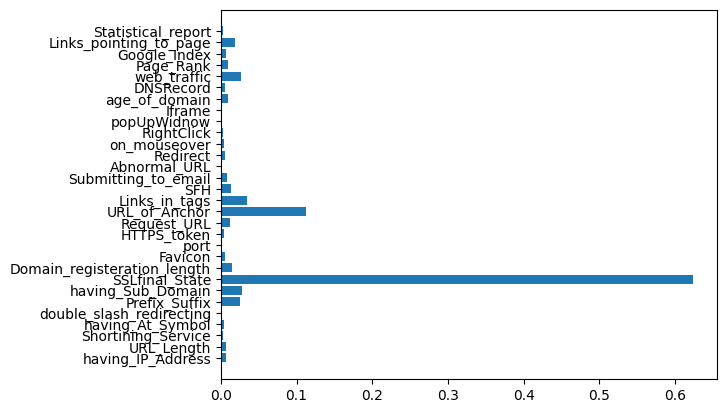

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
plt.barh(x.columns, importances)
plt.show()

In [ ]:
# ============================================================
# CELL: Save trained model and scaler to disk
# Run once after training the model above
# ============================================================
import joblib, os
save_dir = r'D:\Google_Colab\Phishing Detection with decision tress'
joblib.dump(model,  os.path.join(save_dir, 'phishing_model.pkl'))
joblib.dump(scaler, os.path.join(save_dir, 'phishing_scaler.pkl'))
print('Model saved  -> phishing_model.pkl')
print('Scaler saved -> phishing_scaler.pkl')

In [ ]:
# ============================================================
# CELL: Predict phishing from a real URL
# ============================================================
import subprocess, sys, os, warnings

# Install dependencies
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "requests", "beautifulsoup4", "python-whois",
                       "dnspython", "joblib", "-q"])

import joblib
import numpy as np
warnings.filterwarnings("ignore")

# Make feature_extractor importable
project_dir = r'D:\Google_Colab\Phishing Detection with decision tress'
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

from feature_extractor import extract_features

# Load saved model and scaler
clf     = joblib.load(os.path.join(project_dir, "phishing_model.pkl"))
scaler_ = joblib.load(os.path.join(project_dir, "phishing_scaler.pkl"))

# --- Enter URL here ---
url = input("Enter URL to check: ").strip()
print(f"\nExtracting features for: {url}  (may take ~10 s) ...")

try:
    features = extract_features(url)
    scaled   = scaler_.transform([features])
    result   = clf.predict(scaled)[0]
    proba    = clf.predict_proba(scaled)[0]
    conf     = round(max(proba) * 100, 1)

    col_names = [
        "having_IP_Address", "URL_Length", "Shortining_Service",
        "having_At_Symbol", "double_slash_redirecting", "Prefix_Suffix",
        "having_Sub_Domain", "SSLfinal_State", "Domain_registeration_length",
        "Favicon", "port", "HTTPS_token", "Request_URL", "URL_of_Anchor",
        "Links_in_tags", "SFH", "Submitting_to_email", "Abnormal_URL",
        "Redirect", "on_mouseover", "RightClick", "popUpWidnow", "Iframe",
        "age_of_domain", "DNSRecord", "web_traffic", "Page_Rank",
        "Google_Index", "Links_pointing_to_page", "Statistical_report",
    ]

    print("\nFeature Breakdown:")
    print("-" * 52)
    for name, val in zip(col_names, features):
        tag = "[Legit]" if val == 1 else ("[Neutral]" if val == 0 else "[Phish!]")
        print(f"  {tag:<10s} {name:<35s} = {val}")

    print("\n" + "=" * 52)
    verdict = "LEGITIMATE" if result == 1 else "PHISHING DETECTED"
    print(f"  VERDICT : {verdict}  (confidence: {conf}%)")
    print(f"  URL     : {url}")
    print("=" * 52)

except Exception as e:
    import traceback
    print(f"Error during prediction: {e}")
    traceback.print_exc()